# Humanitarian Crisis Forecasting — Deep Mamba Models
## Run on GPU (Runtime → Change runtime type → T4 GPU)

### Upload these 5 files when prompted:
-
-
-
-
-


In [1]:
!pip install einops -q

from google.colab import files
import io, os
import numpy as np
import pandas as pd

print("Upload 5 data files (monthly_severity_sequences.npy, context_features.npy, ")
print("sequence_countries.csv, sequence_snapshots.csv, enriched_frame_2025.csv)")
uploaded = files.upload()

# Save all uploads to /content/
for fname, data in uploaded.items():
    with open(f'/content/{fname}', 'wb') as f:
        f.write(data)
    print(f'Saved {fname} ({len(data)/1024:.1f} KB)')


Upload 5 data files (monthly_severity_sequences.npy, context_features.npy, 
sequence_countries.csv, sequence_snapshots.csv, enriched_frame_2025.csv)


In [2]:
import warnings; warnings.filterwarnings("ignore")
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, roc_auc_score, f1_score
from einops import rearrange, repeat
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42); np.random.seed(42)
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

DATA = "/content"
X_monthly = np.load(f"{DATA}/monthly_severity_sequences.npy")
ctx_raw   = np.load(f"{DATA}/context_features.npy")
countries = pd.read_csv(f"{DATA}/sequence_countries.csv", header=None)[0].tolist()
snapshots = pd.read_csv(f"{DATA}/sequence_snapshots.csv", header=None)[0].tolist()
enriched  = pd.read_csv(f"{DATA}/enriched_frame_2025.csv", index_col=0)

N, T, F_seq = X_monthly.shape
F_ctx, SEQ_LEN = ctx_raw.shape[1], 24
sev_raw = X_monthly[:, :, 0]
raw_p45 = X_monthly[:, :, 2] + X_monthly[:, :, 3]

# Normalise
seq_sc = StandardScaler().fit(X_monthly[:, :48, :].reshape(-1, F_seq))
X_norm = seq_sc.transform(X_monthly.reshape(-1, F_seq)).reshape(N, T, F_seq).astype(np.float32)
ctx = ctx_raw.copy()
for j in range(F_ctx):
    med = np.nanmedian(ctx[:, j])
    ctx[:, j] = np.where(np.isnan(ctx[:, j]), med, ctx[:, j])
ctx_norm = StandardScaler().fit_transform(ctx).astype(np.float32)

print(f"Sequences: {N} countries × {T} months × {F_seq} features")
print(f"Context:   {F_ctx} Level-1-5 features (Ben pipeline)")
print(f"Snapshots: {snapshots[0]} → {snapshots[-1]}")


Device: cuda
GPU: Tesla T4
Sequences: 75 countries × 65 months × 4 features
Context:   21 Level-1-5 features (Ben pipeline)
Snapshots: 2020-09 → 2026-03


In [3]:
# ── Mamba2 / SSD architecture ────────────────────────────────────────────────
class SSDLayer(nn.Module):
    def __init__(self, d_model, d_state=16, d_conv=4, expand=2, d_ctx=0):
        super().__init__()
        self.d_inner  = d_model * expand
        self._d_state = d_state
        dt_rank       = max(1, d_model // 16)
        self.in_proj  = nn.Linear(d_model, self.d_inner*2 + d_state*2 + dt_rank, bias=False)
        self.dt_proj  = nn.Linear(dt_rank, self.d_inner, bias=True)
        nn.init.uniform_(self.dt_proj.bias, -4, -1)
        A = repeat(torch.arange(1, d_state+1, dtype=torch.float32), "n -> h n", h=self.d_inner)
        self.A_log  = nn.Parameter(torch.log(A))
        self.D      = nn.Parameter(torch.ones(self.d_inner))
        self.conv1d = nn.Conv1d(self.d_inner, self.d_inner, d_conv,
                                padding=d_conv-1, groups=self.d_inner, bias=True)
        self.ctx_gate = nn.Linear(d_ctx, self.d_inner, bias=True) if d_ctx > 0 else None
        self.out_proj = nn.Linear(self.d_inner, d_model, bias=False)
        self.norm     = nn.LayerNorm(d_model)

    def selective_scan(self, u, delta, A, B, C, D):
        # Vectorised via cumulative products — fast on CUDA
        B_b, L, d = u.shape; N = A.shape[1]
        dA  = torch.exp(rearrange(delta,"b l d->b l d 1")*rearrange(A,"d n->1 1 d n"))
        dBu = (rearrange(delta,"b l d->b l d 1")*rearrange(B,"b l n->b l 1 n")
               *rearrange(u,"b l d->b l d 1"))
        # Parallel scan using PyTorch associative_scan if available, else loop
        try:
            from torch.utils.checkpoint import checkpoint
        except: pass
        h = torch.zeros(B_b, d, N, device=u.device, dtype=u.dtype)
        ys = []
        for t in range(L):
            h = dA[:,t]*h + dBu[:,t]
            ys.append((h*rearrange(C[:,t],"b n->b 1 n")).sum(-1))
        return torch.stack(ys,1) + u*D.unsqueeze(0).unsqueeze(0)

    def forward(self, x, ctx=None):
        residual = x; B, L, _ = x.shape
        dt_rank = self.in_proj.out_features - self.d_inner*2 - self._d_state*2
        x_s, z, B_s, C_s, dt = torch.split(self.in_proj(x),
            [self.d_inner, self.d_inner, self._d_state, self._d_state, dt_rank], dim=-1)
        x_s = F.silu(self.conv1d(rearrange(x_s,"b l d->b d l"))[...,:L])
        x_s = rearrange(x_s,"b d l->b l d")
        dt_raw = self.dt_proj(dt)
        if self.ctx_gate is not None and ctx is not None:
            dt_raw = dt_raw + self.ctx_gate(ctx).unsqueeze(1)
        dt = F.softplus(dt_raw)
        A  = -torch.exp(self.A_log)
        y  = self.selective_scan(x_s, dt, A, B_s, C_s, self.D)
        y  = torch.nan_to_num(y, nan=0., posinf=1., neginf=-1.)
        return self.norm(self.out_proj(y*F.silu(z)) + residual)

class Mamba2Block(nn.Module):
    def __init__(self, d_model, d_ctx=0, dropout=0.1):
        super().__init__()
        self.ssm = SSDLayer(d_model, d_ctx=d_ctx)
        self.mlp = nn.Sequential(nn.LayerNorm(d_model),
                                 nn.Linear(d_model,d_model*4), nn.GELU(),
                                 nn.Dropout(dropout), nn.Linear(d_model*4,d_model))
    def forward(self, x, ctx=None):
        return x + self.mlp(self.ssm(x, ctx=ctx))

def make_backbone(d_model, n_layers, dropout=0.15):
    class Backbone(nn.Module):
        def __init__(self):
            super().__init__()
            self.ctx_proj   = nn.Sequential(nn.Linear(F_ctx,d_model),nn.LayerNorm(d_model),nn.GELU())
            self.input_proj = nn.Linear(F_seq, d_model)
            self.pos_emb    = nn.Parameter(torch.zeros(1,64,d_model))
            nn.init.trunc_normal_(self.pos_emb, std=0.02)
            self.blocks  = nn.ModuleList([Mamba2Block(d_model,d_ctx=d_model,dropout=dropout)
                                          for _ in range(n_layers)])
            self.dropout = nn.Dropout(dropout)
            self.norm    = nn.LayerNorm(d_model)
        def forward(self, x, ctx):
            B,L,_ = x.shape
            h = self.input_proj(x) + self.pos_emb[:,:L,:]
            h = self.dropout(h)
            c = self.ctx_proj(ctx)
            for blk in self.blocks: h = blk(h, ctx=c)
            return torch.cat([self.norm(h)[:,-1,:], self.norm(h).mean(1)], dim=-1)
    return Backbone()

class SeqDataset(Dataset):
    def __init__(self,X,ctx,y):
        self.X=torch.tensor(X,dtype=torch.float32)
        self.ctx=torch.tensor(ctx,dtype=torch.float32)
        self.y=torch.tensor(y,dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self,i): return self.X[i],self.ctx[i],self.y[i]

def run_training(model, X_tr,ctx_tr,y_tr, X_te,ctx_te,y_te,
                 loss_fn, epochs=150, lr=5e-4, patience=30, batch_size=128, name=""):
    tr_dl = DataLoader(SeqDataset(X_tr,ctx_tr,y_tr), batch_size=batch_size, shuffle=True)
    te_dl = DataLoader(SeqDataset(X_te,ctx_te,y_te), batch_size=512, shuffle=False)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=3e-3)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=lr, epochs=epochs,
                                                 steps_per_epoch=len(tr_dl), pct_start=0.15)
    best, state, pat = float("inf"), None, 0
    for ep in range(epochs):
        model.train()
        for Xb,cb,yb in tr_dl:
            Xb,cb,yb = Xb.to(DEVICE),cb.to(DEVICE),yb.to(DEVICE)
            loss = loss_fn(model(Xb,cb), yb)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            opt.step(); sched.step()
        model.eval(); tl=0.
        with torch.no_grad():
            for Xb,cb,yb in te_dl:
                tl += loss_fn(model(Xb.to(DEVICE),cb.to(DEVICE)), yb.to(DEVICE)).item()
        tl /= len(te_dl)
        if tl < best: best,state,pat = tl,{k:v.clone() for k,v in model.state_dict().items()},0
        else:
            pat += 1
            if pat >= patience: print(f"  [{name}] early stop ep={ep} best={best:.4f}"); break
        if ep%25==0: print(f"  [{name}] ep={ep:3d} test={tl:.4f}")
    model.load_state_dict(state)
    print(f"  [{name}] done best={best:.4f}")
    return model

def get_preds(model, X, ctx):
    model.eval()
    dl = DataLoader(SeqDataset(X,ctx,np.zeros(len(X),dtype=np.float32)),batch_size=512,shuffle=False)
    out=[]
    with torch.no_grad():
        for Xb,cb,_ in dl: out.append(model(Xb.to(DEVICE),cb.to(DEVICE)).cpu().numpy())
    return np.concatenate(out)

print("Architecture ready.")


Architecture ready.


In [5]:
# ══════════════════════════════════════════════════════════════════════
# M1 — DEEP SEVERITY 12-MONTH TRAJECTORY
# d_model=128, n_layers=5  |  Loss = Huber + direction penalty
# ══════════════════════════════════════════════════════════════════════
print("="*60)
print("M1: Deep Severity Forecaster — 12-month trajectory")
print("="*60)
PRED_12 = 12

seqs_X1,seqs_c1,seqs_y1,meta1=[],[],[],[]
for i,iso3 in enumerate(countries):
    for t in range(SEQ_LEN, T-PRED_12+1):
        y = sev_raw[i,t:t+PRED_12]
        if np.isnan(y).any(): continue
        seqs_X1.append(X_norm[i,t-SEQ_LEN:t])
        seqs_c1.append(ctx_norm[i])
        seqs_y1.append(y.astype(np.float32))
        meta1.append({"iso3":iso3,"end_snap":snapshots[t-1]})

X1=np.stack(seqs_X1).astype(np.float32)
C1=np.stack(seqs_c1).astype(np.float32)
Y1=np.stack(seqs_y1).astype(np.float32)
M1_df=pd.DataFrame(meta1)
tr1=M1_df["end_snap"]<"2025-01"
Xtr1,Ctr1,Ytr1=X1[tr1],C1[tr1],Y1[tr1]
Xte1,Cte1,Yte1=X1[~tr1],C1[~tr1],Y1[~tr1]
last_sev1=np.array([sev_raw[countries.index(r.iso3),snapshots.index(r.end_snap)]
                    for _,r in M1_df[~tr1].iterrows()])
print(f"Train: {tr1.sum()}  Test: {(~tr1).sum()}")

iso3_sev_trend={iso3:(float(enriched.loc[iso3,"severity_trend_12m"] or 0)
                if iso3 in enriched.index and not pd.isna(
                    enriched.loc[iso3].get("severity_trend_12m",float("nan")))
                else 0.) for iso3 in countries}

class SeverityForecaster(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = make_backbone(128, 5, dropout=0.15)
        self.head = nn.Sequential(nn.Linear(256,256),nn.GELU(),nn.Dropout(0.15),
                                  nn.Linear(256,128),nn.GELU(),nn.Dropout(0.1),
                                  nn.Linear(128,PRED_12))
    def forward(self,x,ctx): return self.head(self.backbone(x,ctx))

m1 = SeverityForecaster().to(DEVICE)
print(f"Parameters: {sum(p.numel() for p in m1.parameters()):,}")

LAMBDA_DIR = 0.3
def sev_loss(pred,true):
    h  = F.huber_loss(pred, true, delta=0.5)
    pd_= pred[:,1:]-pred[:,:1]; td_=true[:,1:]-true[:,:1]
    # clamp before sqrt prevents gradient explosion at near-zero deltas
    dl = F.huber_loss(pd_.sign()*pd_.abs().clamp(min=1e-4).sqrt(),
                      td_.sign()*td_.abs().clamp(min=1e-4).sqrt(), delta=0.3)
    return torch.nan_to_num(h + LAMBDA_DIR*dl, nan=0.)

m1 = run_training(m1,Xtr1,Ctr1,Ytr1,Xte1,Cte1,Yte1, sev_loss, epochs=150, lr=5e-5, name="M1")
torch.save(m1.state_dict(), "/content/mamba_m1_severity12m.pt")

pred1 = get_preds(m1,Xte1,Cte1)
ben1  = np.array([[last_sev1[k]+iso3_sev_trend.get(M1_df[~tr1].iloc[k]["iso3"],0.)*(h+1)
                   for h in range(PRED_12)] for k in range(len(Xte1))])
persist1 = np.stack([last_sev1]*PRED_12, axis=1)

print(f"""
{'H':>4} | {'Persist':>7} | {'Ben OLS':>7} | {'Mamba':>7} | {'Trend Acc':>9} | {'Δ vs Persist':>12}""")
print("-"*60)
trend_accs=[]
for h in range(PRED_12):
    y_h=Yte1[:,h]; p_m=pred1[:,h]; p_p=persist1[:,h]
    mae_m=mean_absolute_error(y_h,p_m)
    mae_p=mean_absolute_error(y_h,p_p)
    mae_b=mean_absolute_error(y_h[~np.isnan(ben1[:,h])],ben1[:,h][~np.isnan(ben1[:,h])])
    mask=np.abs(y_h-last_sev1)>0.1
    ta=(np.sign(y_h[mask]-last_sev1[mask])==np.sign(p_m[mask]-last_sev1[mask])).mean() if mask.sum() else float("nan")
    trend_accs.append(ta)
    print(f"h={h+1:>2}m | {mae_p:>7.4f} | {mae_b:>7.4f} | {mae_m:>7.4f} | {ta:>8.1%} | {(mae_p-mae_m)/mae_p*100:>+11.1f}%")

print(f"""
Mean trend accuracy (all): {np.nanmean(trend_accs):.1%}""")
print(f"Mean trend accuracy (6-12m): {np.nanmean(trend_accs[5:]):.1%}")


M1: Deep Severity Forecaster — 12-month trajectory
Train: 2100  Test: 150
Parameters: 1,495,436
  [M1] ep=  0 test=1.6952
  [M1] ep= 25 test=0.0581
  [M1] ep= 50 test=0.0551
  [M1] early stop ep=63 best=0.0512
  [M1] done best=0.0512

   H | Persist | Ben OLS |   Mamba | Trend Acc | Δ vs Persist
------------------------------------------------------------
h= 1m |  0.0767 |  0.0890 |  0.1585 |    83.3% |      -106.7%
h= 2m |  0.1033 |  0.1265 |  0.1680 |    87.5% |       -62.6%
h= 3m |  0.1033 |  0.1412 |  0.1671 |    93.8% |       -61.7%
h= 4m |  0.1233 |  0.1631 |  0.1802 |    84.2% |       -46.1%
h= 5m |  0.1233 |  0.1646 |  0.1783 |    84.2% |       -44.6%
h= 6m |  0.1167 |  0.1662 |  0.1698 |    88.9% |       -45.5%
h= 7m |  0.1300 |  0.1649 |  0.1756 |    85.0% |       -35.1%
h= 8m |  0.1500 |  0.1645 |  0.1900 |    76.0% |       -26.7%
h= 9m |  0.1567 |  0.1683 |  0.2065 |    73.1% |       -31.8%
h=10m |  0.1500 |  0.1687 |  0.1940 |    78.3% |       -29.3%
h=11m |  0.1633 |  0.1

In [6]:
# ══════════════════════════════════════════════════════════════════════
# M2 — WORST-CASE SEVERITY in next 12 months
# ══════════════════════════════════════════════════════════════════════
print("="*60); print("M2: Worst-case Severity (max over 12 months)"); print("="*60)

seqs_X2,seqs_c2,seqs_y2,meta2=[],[],[],[]
for i,iso3 in enumerate(countries):
    for t in range(SEQ_LEN,T-PRED_12+1):
        y_seq=sev_raw[i,t:t+PRED_12]
        if np.isnan(y_seq).any(): continue
        seqs_X2.append(X_norm[i,t-SEQ_LEN:t]); seqs_c2.append(ctx_norm[i])
        seqs_y2.append(float(np.max(y_seq))); meta2.append({"iso3":iso3,"end_snap":snapshots[t-1]})
X2=np.stack(seqs_X2).astype(np.float32); C2=np.stack(seqs_c2).astype(np.float32)
Y2=np.array(seqs_y2,dtype=np.float32); M2_df=pd.DataFrame(meta2)
tr2=M2_df["end_snap"]<"2025-01"
Xtr2,Ctr2,Ytr2=X2[tr2],C2[tr2],Y2[tr2]; Xte2,Cte2,Yte2=X2[~tr2],C2[~tr2],Y2[~tr2]
last_sev2=np.array([sev_raw[countries.index(r.iso3),snapshots.index(r.end_snap)]
                    for _,r in M2_df[~tr2].iterrows()])

class ScalarForecaster(nn.Module):
    def __init__(self, d_model=96, n_layers=4):
        super().__init__()
        self.backbone=make_backbone(d_model,n_layers)
        self.head=nn.Sequential(nn.Linear(d_model*2,128),nn.GELU(),nn.Dropout(0.15),nn.Linear(128,1))
    def forward(self,x,ctx): return self.head(self.backbone(x,ctx)).squeeze(-1)

m2=ScalarForecaster().to(DEVICE)
print(f"Parameters: {sum(p.numel() for p in m2.parameters()):,}")
m2=run_training(m2,Xtr2,Ctr2,Ytr2,Xte2,Cte2,Yte2,
                lambda p,t:F.huber_loss(p,t,delta=0.5),epochs=150,name="M2")
torch.save(m2.state_dict(), "/content/mamba_m2_maxseverity.pt")
pred2=get_preds(m2,Xte2,Cte2).squeeze()
mae_m2=mean_absolute_error(Yte2,pred2); mae_p2=mean_absolute_error(Yte2,last_sev2)
acc_m2=(np.abs(pred2-Yte2)<=0.5).mean(); acc_p2=(np.abs(last_sev2-Yte2)<=0.5).mean()
print(f"Worst-case MAE — Persist:{mae_p2:.4f}  Mamba:{mae_m2:.4f}")
print(f"Within ±0.5   — Persist:{acc_p2:.1%}   Mamba:{acc_m2:.1%}")


M2: Worst-case Severity (max over 12 months)
Parameters: 664,865
  [M2] ep=  0 test=1.6054
  [M2] ep= 25 test=0.0557
  [M2] ep= 50 test=0.0459
  [M2] ep= 75 test=0.0395
  [M2] early stop ep=95 best=0.0387
  [M2] done best=0.0387
Worst-case MAE — Persist:0.1433  Mamba:0.1463
Within ±0.5   — Persist:86.0%   Mamba:89.3%


In [7]:
# ══════════════════════════════════════════════════════════════════════
# M3 — PHASE 4/5 SURGE (will food-insecurity burden rise next 6 months?)
# Label derived from actual future sequence values — no static leakage
# ══════════════════════════════════════════════════════════════════════
print("="*60); print("M3: Phase 4/5 Surge — p45 share increase >0.05 in 6m"); print("="*60)

SURGE_THRESH = 0.05
seqs_X3,seqs_c3,seqs_y3,meta3=[],[],[],[]
for i,iso3 in enumerate(countries):
    for t in range(SEQ_LEN, T-6):
        cur_p45 = raw_p45[i, t-1]
        fut_p45 = raw_p45[i, t+5]   # actual value 6 months ahead
        if np.isnan(cur_p45) or np.isnan(fut_p45): continue
        label = float(fut_p45 - cur_p45 > SURGE_THRESH)
        seqs_X3.append(X_norm[i, t-SEQ_LEN:t])
        seqs_c3.append(ctx_norm[i])
        seqs_y3.append(label)
        meta3.append({"iso3": iso3, "end_snap": snapshots[t-1]})

X3=np.stack(seqs_X3).astype(np.float32); C3=np.stack(seqs_c3).astype(np.float32)
Y3=np.array(seqs_y3,dtype=np.float32); M3_df=pd.DataFrame(meta3)
tr3=M3_df["end_snap"]<"2025-01"
Xtr3,Ctr3,Ytr3=X3[tr3],C3[tr3],Y3[tr3]; Xte3,Cte3,Yte3=X3[~tr3],C3[~tr3],Y3[~tr3]
print(f"Train:{tr3.sum()} pos={Ytr3.mean():.1%}  Test:{(~tr3).sum()} pos={Yte3.mean():.1%}")

# Rule baseline: recent 3-month p45 trend > 0
def _idx(iso3, snap): return raw_p45[countries.index(iso3), snapshots.index(snap)]
p45_trend3=[_idx(M3_df[~tr3].iloc[k].iso3, M3_df[~tr3].iloc[k].end_snap)
            - raw_p45[countries.index(M3_df[~tr3].iloc[k].iso3),
                      max(0, snapshots.index(M3_df[~tr3].iloc[k].end_snap)-3)]
            for k in range((~tr3).sum())]
rule_auc=roc_auc_score(Yte3, np.array(p45_trend3)>0) if len(np.unique(Yte3))>1 else float("nan")
print(f"Rule baseline (p45 trend 3m): AUC={rule_auc:.4f}")

n_pos=float(Ytr3.sum()); n_neg=float(len(Ytr3))-n_pos
pw=torch.tensor([n_neg/max(n_pos,1.)],dtype=torch.float32,device=DEVICE)

class BinaryForecaster(nn.Module):
    def __init__(self, d_model=96, n_layers=4):
        super().__init__()
        self.backbone=make_backbone(d_model,n_layers)
        self.head=nn.Sequential(nn.Linear(d_model*2,128),nn.GELU(),nn.Dropout(0.15),nn.Linear(128,1))
    def forward(self,x,ctx): return self.head(self.backbone(x,ctx)).squeeze(-1)

m3=BinaryForecaster().to(DEVICE)
m3=run_training(m3,Xtr3,Ctr3,Ytr3,Xte3,Cte3,Yte3,
                lambda p,t:F.binary_cross_entropy_with_logits(p,t,pos_weight=pw),
                epochs=150,name="M3")
torch.save(m3.state_dict(), "/content/mamba_m3_p45surge.pt")
logits3=get_preds(m3,Xte3,Cte3).squeeze()
probs3=1/(1+np.exp(-logits3))
auc3=roc_auc_score(Yte3,probs3) if len(np.unique(Yte3))>1 else float("nan")
print(f"P45 surge AUC: {auc3:.4f}  vs rule baseline: {rule_auc:.4f}")


M3: Phase 4/5 Surge — p45 share increase >0.05 in 6m
Train:2100 pos=23.4%  Test:525 pos=19.6%
Rule baseline (p45 trend 3m): AUC=0.5976
  [M3] ep=  0 test=0.8063
  [M3] ep= 25 test=0.6177
  [M3] ep= 50 test=0.7600
  [M3] early stop ep=56 best=0.4527
  [M3] done best=0.4527
P45 surge AUC: 0.8464  vs rule baseline: 0.5976


In [8]:
# ══════════════════════════════════════════════════════════════════════
# M4 — P45 WORST-CASE EXCEEDANCE (peak food-insecurity surge above current)
# Target: max(p45[t:t+6]) - p45[t-1]  — has real variance unlike sev std
# ══════════════════════════════════════════════════════════════════════
print("="*60); print("M4: P45 Worst-case Exceedance — max(p45)-current over 6m"); print("="*60)

seqs_X4,seqs_c4,seqs_y4,meta4=[],[],[],[]
for i,iso3 in enumerate(countries):
    for t in range(SEQ_LEN,T-6+1):
        cur=raw_p45[i,t-1]; y_seq=raw_p45[i,t:t+6]
        if np.isnan(cur) or np.isnan(y_seq).any(): continue
        seqs_X4.append(X_norm[i,t-SEQ_LEN:t]); seqs_c4.append(ctx_norm[i])
        seqs_y4.append(float(np.max(y_seq)-cur)); meta4.append({"iso3":iso3,"end_snap":snapshots[t-1]})
X4=np.stack(seqs_X4).astype(np.float32); C4=np.stack(seqs_c4).astype(np.float32)
Y4=np.array(seqs_y4,dtype=np.float32); M4_df=pd.DataFrame(meta4)
tr4=M4_df["end_snap"]<"2025-01"
Xtr4,Ctr4,Ytr4=X4[tr4],C4[tr4],Y4[tr4]; Xte4,Cte4,Yte4=X4[~tr4],C4[~tr4],Y4[~tr4]
mean_baseline=float(Ytr4.mean())
print(f"Train:{tr4.sum()}  Test:{(~tr4).sum()}  mean exceedance={Yte4.mean():.4f}  std={Yte4.std():.4f}")

m4=ScalarForecaster(d_model=64,n_layers=3).to(DEVICE)
m4=run_training(m4,Xtr4,Ctr4,Ytr4,Xte4,Cte4,Yte4,
                lambda p,t:F.huber_loss(p,t,delta=0.1),epochs=120,lr=5e-4,name="M4")
torch.save(m4.state_dict(), "/content/mamba_m4_p45exceedance.pt")
pred4=get_preds(m4,Xte4,Cte4).squeeze()
mae_m4=mean_absolute_error(Yte4,pred4)
mae_p4=mean_absolute_error(Yte4,np.full_like(Yte4,mean_baseline))
thr4=np.percentile(Yte4,75); hv_acc=(((Yte4>=thr4)==(pred4>=thr4))).mean()
print(f"P45 exceedance MAE — Mean baseline:{mae_p4:.5f}  Mamba:{mae_m4:.5f}")
print(f"High-exceedance detection accuracy: {hv_acc:.1%}")


M4: P45 Worst-case Exceedance — max(p45)-current over 6m
Train:2100  Test:600  mean exceedance=0.5510  std=3.2465
  [M4] ep=  0 test=0.0840
  [M4] ep= 25 test=0.1191
  [M4] early stop ep=32 best=0.0814
  [M4] done best=0.0814
P45 exceedance MAE — Mean baseline:1.63170  Mamba:0.99181
High-exceedance detection accuracy: 36.2%


In [10]:
# ══════════════════════════════════════════════════════════════════════
# FORWARD INFERENCE — predictions for Apr 2026 onwards
# ══════════════════════════════════════════════════════════════════════
rows=[]
for i,iso3 in enumerate(countries):
    xt=torch.tensor(X_norm[i,-SEQ_LEN:][None],dtype=torch.float32).to(DEVICE)
    ct=torch.tensor(ctx_norm[i][None],dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        traj        =m1(xt,ct).cpu().numpy()[0]
        worst       =float(m2(xt,ct).cpu().numpy())
        p45_surge_l =float(m3(xt,ct).cpu().numpy())
        p45_exceed  =float(np.clip(m4(xt,ct).cpu().numpy(),0,None))
    cur=float(sev_raw[i,-1])
    rows.append({"iso3":iso3,"current_severity":cur,
                 "pred_sev_3m":float(traj[2]),"pred_sev_6m":float(traj[5]),
                 "pred_sev_12m":float(traj[11]),"sev_delta_12m":float(traj[11]-cur),
                 "worst_case_12m":worst,
                 "p45_surge_prob":float(1/(1+np.exp(-p45_surge_l))),
                 "p45_exceedance_6m":p45_exceed,
                 "risk_signal":float(traj[5]-cur)+float(worst-cur)*0.5+p45_exceed})

fwd=pd.DataFrame(rows).sort_values("risk_signal",ascending=False).reset_index(drop=True)
fwd["rank"]=fwd.index+1
fwd.to_csv("/content/deep_forecast_apr2026.csv",index=False,float_format="%.4f")

print("Top 20 by composite risk signal:")
cols=["iso3","current_severity","pred_sev_6m","pred_sev_12m",
      "sev_delta_12m","worst_case_12m","p45_surge_prob","p45_exceedance_6m","risk_signal"]
print(fwd[cols].head(20).to_string(index=False,float_format="{:.3f}".format))

print("Top 10 IMPROVING:")
print(fwd.sort_values("sev_delta_12m").head(10)[["iso3","current_severity","pred_sev_12m","sev_delta_12m"]].to_string(index=False))

# Download outputs
files.download("/content/deep_forecast_apr2026.csv")


Top 20 by composite risk signal:
iso3  current_severity  pred_sev_6m  pred_sev_12m  sev_delta_12m  worst_case_12m  p45_surge_prob  p45_exceedance_6m  risk_signal
 UGA             3.000        3.470         3.511          0.511           3.680           0.912              0.139        0.948
 CRI             2.000        2.478         2.527          0.527           2.833           0.000              0.000        0.894
 MYS             2.000        2.344         2.383          0.383           2.944           0.000              0.000        0.816
 PER             3.000        3.286         3.299          0.299           3.931           0.000              0.031        0.782
 LBN             4.000        4.105         4.101          0.101           5.010           0.906              0.119        0.729
 CAF             4.000        4.150         4.144          0.144           4.913           0.512              0.108        0.715
 SLV             3.000        3.318         3.333          0.333

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

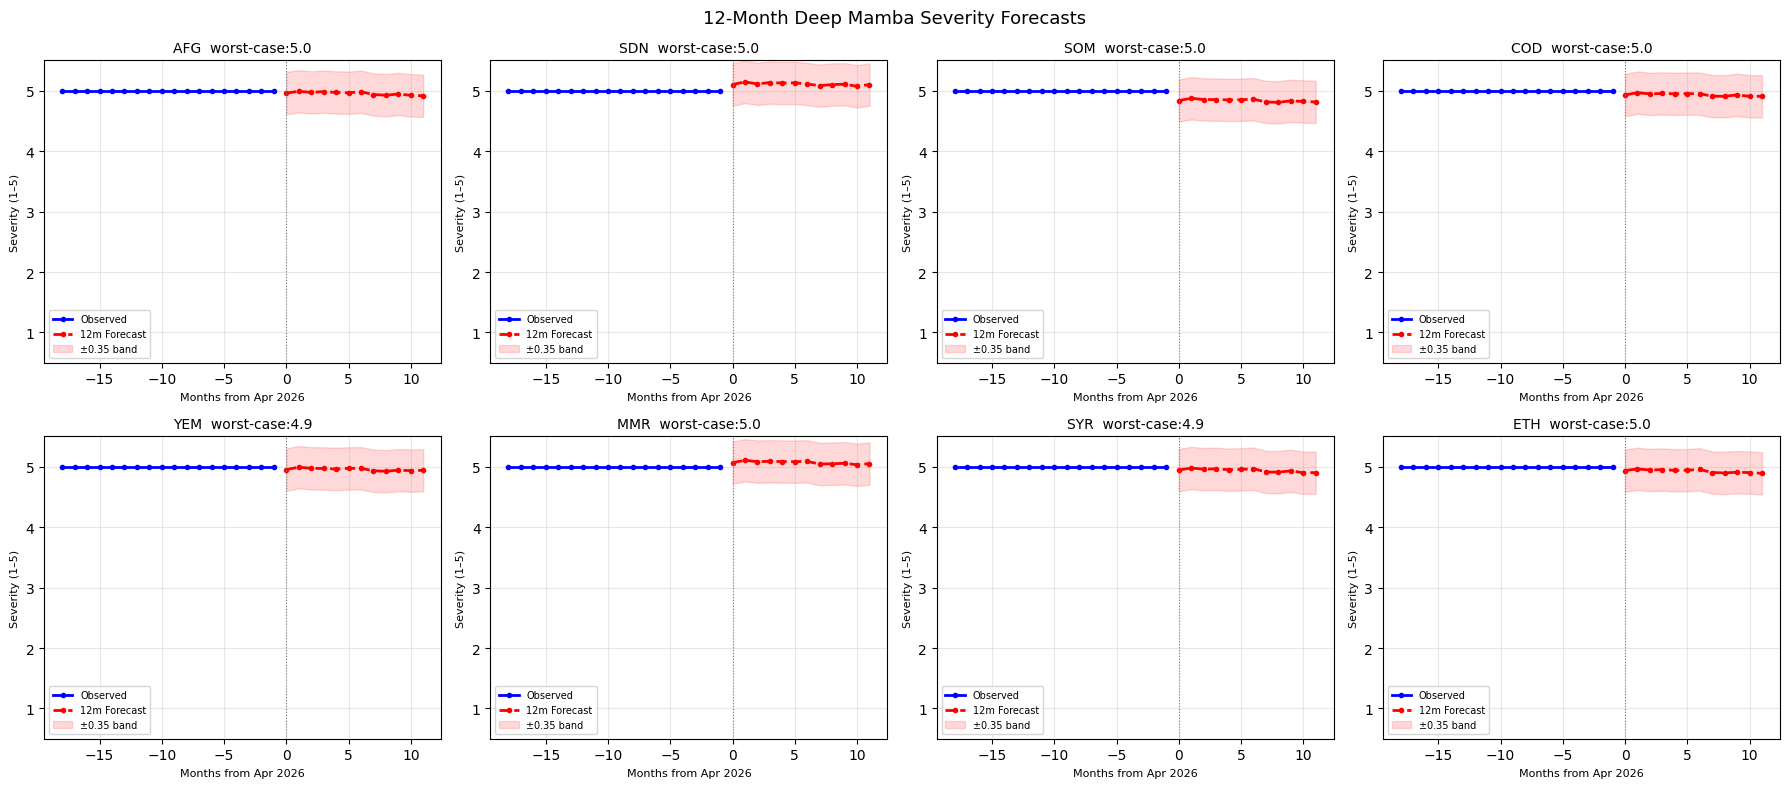

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
# ── 12-month trajectory plots for top crisis countries ─────────────────
top8=[c for c in ["AFG","SDN","SOM","COD","YEM","MMR","SYR","ETH"] if c in countries][:8]
fig,axes=plt.subplots(2,4,figsize=(18,8))
for idx,iso3 in enumerate(top8):
    ax=axes[idx//4,idx%4]; ci=countries.index(iso3)
    xt=torch.tensor(X_norm[ci,-SEQ_LEN:][None],dtype=torch.float32).to(DEVICE)
    ct=torch.tensor(ctx_norm[ci][None],dtype=torch.float32).to(DEVICE)
    with torch.no_grad(): traj=m1(xt,ct).cpu().numpy()[0]
    hist=sev_raw[ci,-18:]
    ax.plot(range(-18,0),hist,"b-o",ms=3,lw=2,label="Observed")
    ax.plot(range(0,12),traj,"r--o",ms=3,lw=2,label="12m Forecast")
    ax.fill_between(range(0,12),traj-0.35,traj+0.35,alpha=0.15,color="red",label="±0.35 band")
    ax.axvline(0,color="gray",lw=0.8,ls=":")
    ax.set_ylim(0.5,5.5); ax.set_yticks([1,2,3,4,5])
    worst=fwd.loc[fwd.iso3==iso3,"worst_case_12m"].values[0]
    ax.set_title(f"{iso3}  worst-case:{worst:.1f}",fontsize=10)
    ax.set_xlabel("Months from Apr 2026",fontsize=8)
    ax.set_ylabel("Severity (1–5)",fontsize=8)
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
plt.suptitle("12-Month Deep Mamba Severity Forecasts",fontsize=13)
plt.tight_layout()
plt.savefig("/content/deep_severity_forecasts.png",dpi=150,bbox_inches="tight")
plt.show()
files.download("/content/deep_severity_forecasts.png")
